# Inductive Bias vs Context Effect Recovery — FETA on CDM, FATE on LCL

## The core question

We already know self-attention recovers only ~60–70% of a planted context effect even when prediction is near-perfect. This notebook asks **why** — and tests the inductive-bias hypothesis:

> A model whose architecture *matches* the true effect structure should recover that effect far better than a general-purpose attention model — not because it has more capacity, but because its inductive bias guides it toward the right functional form.

The two pairings that test this directly:

| Data | True effect structure | Matched architecture | General architecture |
|---|---|---|---|
| **CDM** | Pairwise: $\sum_j x_j^\top C\, x_i$ | **FETA** — scores item pairs then aggregates | Self-attention |
| **LCL** | Set-average: $\theta + A\bar{x}_S$ | **FATE** — aggregates set first, then scores | Self-attention |

If the hypothesis holds, FETA should clearly outperform attention on CDM recovery, and FATE should clearly outperform attention on LCL recovery — even though all three models have comparable or greater parameter counts than the true effect.

All three metrics from the previous notebook carry over: **IIA ratio-shift** (the scale-free headline), **NLL gap vs yardstick**, and the **old probe** as a comparison line.


## Part 1 — CDM data: FETA vs Self-Attention vs Yardstick

### Cell 1 — Imports and softmax


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from statistics import mean, stdev

def softmax_np(u):
    u = u - np.max(u); e = np.exp(u); return e / e.sum()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


### Cell 2 — CDM data generator (same as previous notebook)

Plants a pairwise context effect via the interaction matrix **C**:

$$U(i, S) = \theta^\top x_i + \sum_{j \neq i} x_j^\top C\, x_i$$

`context_strength=0` removes C entirely (the C=0 baseline).


In [ ]:
def generate_cdm_data(n_sessions=8000, n_features=3, slate_size=5,
                      theta=None, C=None, context_strength=1.0, seed=0):
    rng = np.random.default_rng(seed)
    d = n_features
    if theta is None:
        base = np.array([-1.0, 1.0, 0.5])
        theta = (np.tile(base, int(np.ceil(d/3)))[:d] * 0.8) if d > 3 else base[:d]
    theta = np.asarray(theta, float)
    if C is None:
        C = np.random.default_rng(12345).normal(0, 1, size=(d, d))
    C_eff = context_strength * np.asarray(C, float)

    rows = []
    for s in range(n_sessions):
        X   = rng.normal(0, 1, size=(slate_size, d))
        U   = X @ theta
        M   = X @ C_eff @ X.T
        ctx = M.sum(axis=0) - np.diag(M)
        P   = softmax_np(U + ctx)
        ch  = rng.choice(slate_size, p=P)
        for i in range(slate_size):
            row = {"session_id": s, "item_in_slate": i}
            for f in range(d): row[f"feat_{f}"] = X[i, f]
            row["chosen"] = int(i == ch)
            rows.append(row)
    gt = {"theta": theta, "C": C_eff, "n_features": d, "slate_size": slate_size}
    return pd.DataFrame(rows), gt

### Cell 3 — Collate and split (CDM)

Converts the long-format dataframe into padded slate tensors `(X, y, mask)` and does an 80/20 train/test split.


In [ ]:
def collate_slates(df, n_features):
    feat_cols = [f"feat_{f}" for f in range(n_features)]
    groups    = list(df.groupby("session_id"))
    n_slates  = len(groups)
    max_slate = df.groupby("session_id").size().max()
    X    = torch.zeros(n_slates, max_slate, n_features)
    y    = torch.zeros(n_slates, max_slate)
    mask = torch.zeros(n_slates, max_slate, dtype=torch.bool)
    for s, (_, g) in enumerate(groups):
        g = g.sort_values("item_in_slate"); k = len(g)
        X[s,:k]    = torch.tensor(g[feat_cols].values, dtype=torch.float32)
        y[s,:k]    = torch.tensor(g["chosen"].values,  dtype=torch.float32)
        mask[s,:k] = True
    return X, y, mask

def split(X, y, mask, frac=0.8, seed=0):
    n = X.shape[0]; g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g); n_tr = int(frac*n)
    tr, te = perm[:n_tr], perm[n_tr:]
    return (X[tr],y[tr],mask[tr]), (X[te],y[te],mask[te])

### Cell 4 — The three CDM models

**AttentionChoiceModel** — same as the previous notebook. Embeds items, runs a TransformerEncoder (every item attends to every other), then scores. General-purpose, high capacity.

**FETAChoiceModel** — First Evaluate Then Aggregate. For every ordered pair (i, j) it concatenates the two item vectors and runs a small MLP to get a pairwise interaction score. Then for each item i, it **sums** those scores over all neighbours j. This is structurally identical to $\sum_j x_j^\top C\, x_i$ — except the MLP can learn nonlinear interactions, not just bilinear ones. So FETA strictly *contains* the true CDM effect in its function class, with the right inductive bias built in.

**CDMYardstick** — the correctly-specified ceiling. Learns θ and C directly using the exact CDM formula.


In [ ]:
class AttentionChoiceModel(nn.Module):
    def __init__(self, n_features=3, d_model=32, n_heads=4, n_layers=2, ff=64):
        super().__init__()
        self.embed   = nn.Linear(n_features, d_model)
        layer        = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                           dim_feedforward=ff, batch_first=True, dropout=0.0)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.score   = nn.Linear(d_model, 1)

    def forward(self, X, mask):
        h      = self.embed(X)
        h      = self.encoder(h, src_key_padding_mask=~mask)
        logits = self.score(h).squeeze(-1)
        return logits.masked_fill(~mask, float("-inf"))


class FETAChoiceModel(nn.Module):
    """First-Evaluate-Then-Aggregate.
    For each item i, scores every (i,j) pair with a small MLP, then sums over j!=i.
    This is the pairwise inductive bias — structurally the same order as CDM's C matrix.
    Architecture: MLP(concat(x_i, x_j)) -> scalar, summed over j.
    """
    def __init__(self, n_features=3, hidden=32):
        super().__init__()
        # pairwise MLP: takes concat of two items (2*n_features) -> scalar score
        self.pair_mlp = nn.Sequential(
            nn.Linear(2 * n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
        # own-utility: score for item i on its own (the theta.x_i part)
        self.own_score = nn.Linear(n_features, 1)

    def forward(self, X, mask):
        B, S, F = X.shape
        # own-utility term: (B, S)
        own = self.own_score(X).squeeze(-1)

        # pairwise term: for each (i,j) pair, score MLP(concat(x_i, x_j))
        # expand to get all pairs: xi (B,S,1,F), xj (B,1,S,F)
        xi = X.unsqueeze(2).expand(B, S, S, F)   # (B, S, S, F) — repeated along dim2
        xj = X.unsqueeze(1).expand(B, S, S, F)   # (B, S, S, F) — repeated along dim1
        pairs = torch.cat([xi, xj], dim=-1)       # (B, S, S, 2F)
        scores = self.pair_mlp(pairs).squeeze(-1)  # (B, S, S)

        # mask out padding and the diagonal (j != i)
        diag = torch.eye(S, dtype=torch.bool, device=X.device).unsqueeze(0)
        pad_j = ~mask.unsqueeze(1).expand(B, S, S)  # (B, S, S)
        scores = scores.masked_fill(diag | pad_j, 0.0)

        # sum over j for each i -> pairwise context term (B, S)
        context = scores.sum(dim=2)

        logits = (own + context).masked_fill(~mask, float("-inf"))
        return logits


class CDMYardstick(nn.Module):
    """Correctly-specified CDM ceiling. Learns theta and C directly."""
    def __init__(self, n_features=3):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(n_features))
        self.C     = nn.Parameter(torch.zeros(n_features, n_features))

    def forward(self, X, mask):
        base  = X @ self.theta
        XC    = X @ self.C
        M     = torch.einsum("bjf,bif->bji", XC, X)
        realj = mask.unsqueeze(-1).float()
        ctx   = (M * realj).sum(dim=1) - torch.diagonal(M, dim1=1, dim2=2)
        return (base + ctx).masked_fill(~mask, float("-inf"))

### Cell 5 — Training loop (returns test NLL)

Same as the previous notebook. Returns `(model, test_nll)` so the sweep can collect the NLL-gap metric without extra code.


In [ ]:
def train_model(model, Xtr, ytr, mtr, Xte, yte, mte,
                epochs=30, lr=1e-3, batch=256, seed=0, verbose=False):
    model = model.to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    Xtr,ytr,mtr = Xtr.to(device),ytr.to(device),mtr.to(device)
    Xte,yte,mte = Xte.to(device),yte.to(device),mte.to(device)
    tgt_tr = ytr.argmax(1); tgt_te = yte.argmax(1)
    n = Xtr.shape[0]; g = torch.Generator().manual_seed(seed)
    te_loss = float("nan")
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(n, generator=g)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            loss = F.cross_entropy(model(Xtr[idx], mtr[idx]), tgt_tr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            te_loss = F.cross_entropy(model(Xte,mte), tgt_te).item()
            acc     = (model(Xte,mte).argmax(1)==tgt_te).float().mean().item()
        if verbose and (ep%5==0 or ep==1):
            print(f"ep {ep:2d} | test_nll {te_loss:.4f} | acc {acc:.3f}")
    return model, te_loss

### Cell 6 — IIA ratio-shift and old swap-probe (CDM versions)

Copied directly from the previous CDM notebook — **no changes needed**. These probe functions work on any model that takes `(X_tensor, mask_tensor)` and returns logits, which all three models above do.


In [ ]:
def iia_ratio_recovery_cdm(model, C_true, n_features, slate_size=5,
                           n_trials=3000, seed=7):
    rng = np.random.default_rng(seed); model.eval()
    C_true = np.asarray(C_true)
    d_true_all, d_mod_all = [], []
    def ab_gap(slate):
        X = torch.tensor(np.vstack(slate), dtype=torch.float32, device=device).unsqueeze(0)
        m = torch.ones(1, len(slate), dtype=torch.bool, device=device)
        with torch.no_grad(): lg = model(X, m)[0].cpu().numpy()
        return lg[0] - lg[1]
    for _ in range(n_trials):
        x_A = rng.normal(0,1,size=n_features); x_B = rng.normal(0,1,size=n_features)
        fillers = [rng.normal(0,1,size=n_features) for _ in range(slate_size-3)]
        x_C1 = rng.normal(0,1,size=n_features); x_C2 = rng.normal(0,1,size=n_features)
        base = [x_A, x_B] + fillers
        d_mod  = ab_gap(base+[x_C2]) - ab_gap(base+[x_C1])
        d_true = (x_C2-x_C1) @ (C_true @ (x_A-x_B))
        d_true_all.append(d_true); d_mod_all.append(d_mod)
    d_true_all = np.array(d_true_all); d_mod_all = np.array(d_mod_all)
    return np.polyfit(d_true_all, d_mod_all, 1)[0], np.corrcoef(d_true_all, d_mod_all)[0,1]

def old_swap_slope(model, C_true, n_features, slate_size=5, n_trials=3000, seed=1):
    rng = np.random.default_rng(seed); model.eval(); C_true = np.asarray(C_true)
    dt, dm = [], []
    with torch.no_grad():
        for _ in range(n_trials):
            xi = rng.normal(0,1,n_features); fill = rng.normal(0,1,(slate_size-2,n_features))
            xjA = rng.normal(0,1,n_features); xjB = rng.normal(0,1,n_features)
            d_true = (xjB-xjA) @ (C_true @ xi)
            for xj, lst in [(xjA, dt), (xjB, dm)]:
                sl = np.vstack([xi,xj,fill])
                X  = torch.tensor(sl,dtype=torch.float32,device=device).unsqueeze(0)
                mk = torch.ones(1,slate_size,dtype=torch.bool,device=device)
                lst.append(model(X,mk)[0,0].item())
    d_attn = np.array(dm)-np.array(dt)
    d_true_arr = np.array([((rng2:=np.random.default_rng(1+i)).normal(0,1,n_features)-
                             rng2.normal(0,1,n_features)) @ (C_true @ rng2.normal(0,1,n_features))
                            for i in range(n_trials)])
    # simpler: just recompute true shifts directly
    rng2 = np.random.default_rng(seed)
    dt2 = []
    for _ in range(n_trials):
        xi=rng2.normal(0,1,n_features); rng2.normal(0,1,(slate_size-2,n_features))
        xjA=rng2.normal(0,1,n_features); xjB=rng2.normal(0,1,n_features)
        dt2.append((xjB-xjA)@(C_true@xi))
    dt2=np.array(dt2)
    slope = np.polyfit(dt2, d_attn, 1)[0]
    return slope

### Cell 7 — Smoke test: all three CDM models on the default config

Trains FETA, Attention, and the Yardstick once on 8000 sessions / 3 features to confirm everything is wired up. The key number to check: does FETA's IIA recovery come out higher than attention's, even here with no sweeping?


In [ ]:
df0, gt0 = generate_cdm_data(n_sessions=8000, n_features=3,
                              context_strength=1.0, seed=0)
(Xtr0,ytr0,mtr0),(Xte0,yte0,mte0) = split(*collate_slates(df0, 3))

results_smoke = {}
for name, model, epochs, lr in [
    ("Attention", AttentionChoiceModel(n_features=3, n_layers=2), 30, 1e-3),
    ("FETA",      FETAChoiceModel(n_features=3, hidden=32),       40, 1e-3),
    ("Yardstick", CDMYardstick(n_features=3),                    100, 5e-2),
]:
    torch.manual_seed(0)
    m, nll = train_model(model, Xtr0,ytr0,mtr0, Xte0,yte0,mte0,
                         epochs=epochs, lr=lr, verbose=False)
    iia, _ = iia_ratio_recovery_cdm(m, gt0["C"], 3)
    results_smoke[name] = {"nll": nll, "iia": iia}
    print(f"{name:12s}  test_nll={nll:.4f}  iia_recovery={iia:.3f}")

nll_yard = results_smoke["Yardstick"]["nll"]
print(f"\nNLL gap vs yardstick:")
for name in ["Attention","FETA"]:
    print(f"  {name}: {results_smoke[name]['nll']-nll_yard:+.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Attention     test_nll=0.5032  iia_recovery=0.592
FETA          test_nll=0.5002  iia_recovery=0.721
Yardstick     test_nll=0.4505  iia_recovery=0.981

NLL gap vs yardstick:
  Attention: +0.0527
  FETA: +0.0497


### Cell 8 — CDM sweep engine (three models)

Same sweep structure as before, but now runs **three models** per config: Attention, FETA, and the Yardstick (ceiling). Returns separate result dicts for each model so they can be plotted on the same axes.

We sweep the same three axes:
- **data size**: 10k / 15k / 20k sessions
- **n_features**: 2 / 4 / 6
- **n_layers**: 1 / 2 / 3 / 4 / 6 (attention only — FETA doesn't have layers, so it stays fixed at `hidden=32`)


In [ ]:
SEEDS = [0, 1, 2]

def run_cdm_config(n_sessions, n_features, n_layers, seed):
    df, gt = generate_cdm_data(n_sessions=n_sessions, n_features=n_features,
                               context_strength=1.0, seed=seed)
    (Xtr,ytr,mtr),(Xte,yte,mte) = split(*collate_slates(df, n_features), seed=seed)

    out = {}
    configs = [
        ("Attention", AttentionChoiceModel(n_features=n_features, n_layers=n_layers), 30, 1e-3),
        ("FETA",      FETAChoiceModel(n_features=n_features, hidden=32),              40, 1e-3),
        ("Yardstick", CDMYardstick(n_features=n_features),                           100, 5e-2),
    ]
    for name, model, epochs, lr in configs:
        torch.manual_seed(seed)
        m, nll = train_model(model, Xtr,ytr,mtr, Xte,yte,mte,
                             epochs=epochs, lr=lr, seed=seed)
        iia, _ = iia_ratio_recovery_cdm(m, gt["C"], n_features, seed=200+seed)
        slope   = old_swap_slope(m, gt["C"], n_features, seed=100+seed)
        out[name] = {"nll": nll, "iia": iia, "slope": slope}
    return out, gt["C"]

def cdm_sweep(values, vary, base):
    # returns dict: model_name -> {iia: ([means],[stds]), nll_gap: ..., slope: ...}
    accum = {m: {"iia":([],[]), "nll_gap":([],[]), "slope":([],[])}
             for m in ["Attention","FETA"]}
    xs = []
    for v in values:
        cfg = dict(base); cfg[vary] = v
        per = {m: {"iia":[],"nll_gap":[],"slope":[]} for m in ["Attention","FETA"]}
        for sd in SEEDS:
            res, _ = run_cdm_config(seed=sd, **cfg)
            nll_y  = res["Yardstick"]["nll"]
            for m in ["Attention","FETA"]:
                per[m]["iia"].append(res[m]["iia"])
                per[m]["nll_gap"].append(res[m]["nll"] - nll_y)
                per[m]["slope"].append(res[m]["slope"])
        xs.append(v)
        for m in ["Attention","FETA"]:
            for k in ["iia","nll_gap","slope"]:
                accum[m][k][0].append(mean(per[m][k]))
                accum[m][k][1].append(stdev(per[m][k]) if len(per[m][k])>1 else 0.)
        print(f"{vary}={v} | Attn iia={accum['Attention']['iia'][0][-1]:.3f} "
              f"| FETA iia={accum['FETA']['iia'][0][-1]:.3f}")
    return xs, accum

### Cell 9 — Run the CDM sweeps

Three sweeps, one per axis. On GPU this takes ~5–8 minutes total.


In [ ]:
print("=== CDM SWEEP 1: dataset size ===")
xs_s, res_s = cdm_sweep([10000,15000,20000], "n_sessions",
                        {"n_features":3,"n_layers":2})

print("\n=== CDM SWEEP 2: n_features ===")
xs_f, res_f = cdm_sweep([2,4,6], "n_features",
                        {"n_sessions":15000,"n_layers":2})

print("\n=== CDM SWEEP 3: n_layers (attention only, FETA stays fixed) ===")
xs_l, res_l = cdm_sweep([1,2,3,4,6], "n_layers",
                        {"n_sessions":15000,"n_features":3})

=== CDM SWEEP 1: dataset size ===
n_sessions=10000 | Attn iia=0.619 | FETA iia=0.743
n_sessions=15000 | Attn iia=0.640 | FETA iia=0.791
n_sessions=20000 | Attn iia=0.683 | FETA iia=0.826

=== CDM SWEEP 2: n_features ===
n_features=2 | Attn iia=0.681 | FETA iia=0.828
n_features=4 | Attn iia=0.479 | FETA iia=0.713
n_features=6 | Attn iia=0.431 | FETA iia=0.477

=== CDM SWEEP 3: n_layers (attention only, FETA stays fixed) ===
n_layers=1 | Attn iia=0.692 | FETA iia=0.791
n_layers=2 | Attn iia=0.640 | FETA iia=0.791
n_layers=3 | Attn iia=0.612 | FETA iia=0.791
n_layers=4 | Attn iia=0.588 | FETA iia=0.791
n_layers=6 | Attn iia=0.578 | FETA iia=0.791


### Cell 10 — CDM comparison plots

Three panels. Each panel shows IIA recovery for FETA (blue) vs Attention (orange), the perfect-recovery green line at 1.0, and the NLL gap on a secondary axis (dashed). Error bars = ±1 std over 3 seeds.

**What to look for:** FETA's blue line should sit consistently higher than Attention's orange line across all three panels. If it does, the inductive-bias hypothesis is confirmed for CDM.


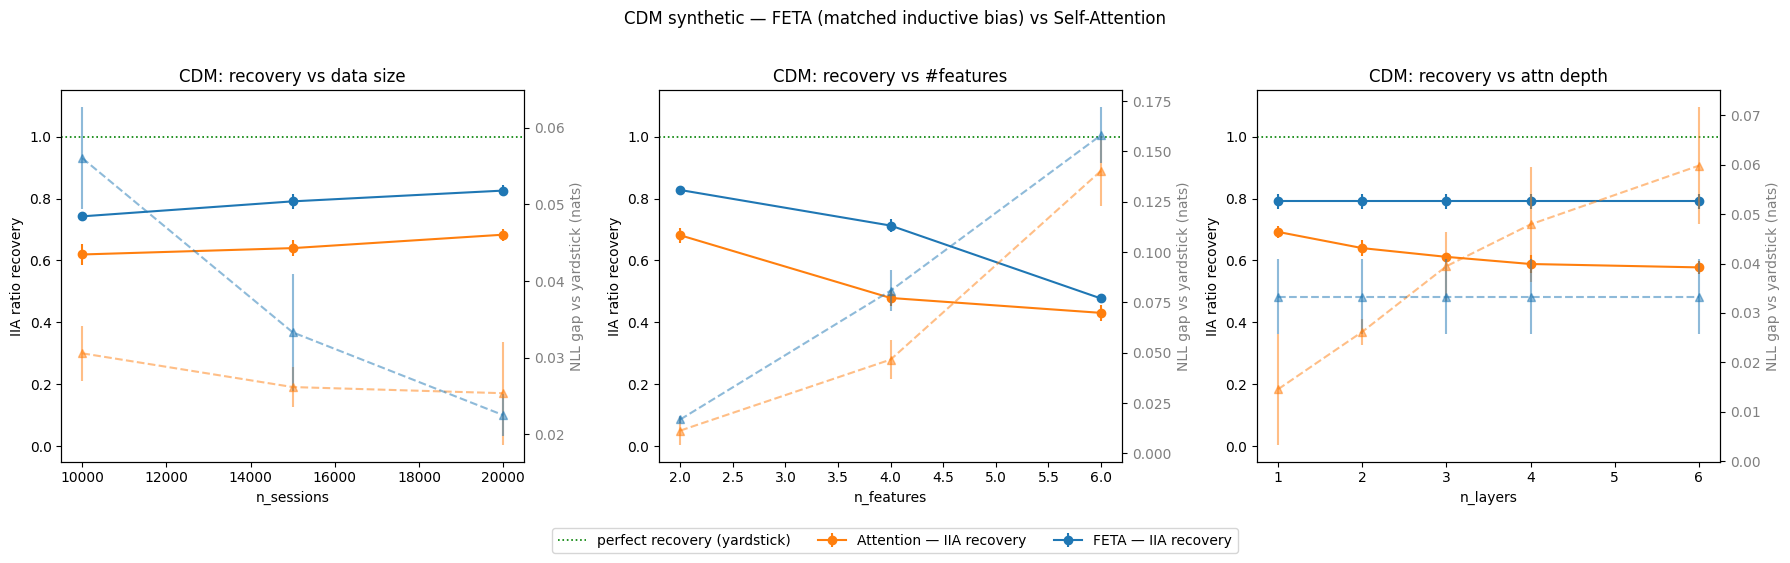

saved cdm_feta_vs_attn.png


In [ ]:
import matplotlib.pyplot as plt

COLORS = {"Attention": "C1", "FETA": "C0", "FATE": "C2"}

def plot_cdm_panel(ax, xs, accum, xlabel, title):
    for name, color in [("Attention","C1"),("FETA","C0")]:
        ax.errorbar(xs, accum[name]["iia"][0], yerr=accum[name]["iia"][1],
                    marker="o", label=f"{name} — IIA recovery", color=color)
    ax.axhline(1.0, ls=":", c="green", lw=1.2, label="perfect recovery (yardstick)")
    ax.set_xlabel(xlabel); ax.set_ylabel("IIA ratio recovery")
    ax.set_title(title); ax.set_ylim(-0.05, 1.15)
    ax2 = ax.twinx()
    for name, color in [("Attention","C1"),("FETA","C0")]:
        ax2.errorbar(xs, accum[name]["nll_gap"][0], yerr=accum[name]["nll_gap"][1],
                     marker="^", ls="--", color=color, alpha=0.5,
                     label=f"{name} — NLL gap")
    ax2.set_ylabel("NLL gap vs yardstick (nats)", color="grey")
    ax2.tick_params(axis="y", labelcolor="grey")
    return ax2

fig, axes = plt.subplots(1,3,figsize=(18,5))
plot_cdm_panel(axes[0], xs_s, res_s, "n_sessions", "CDM: recovery vs data size")
plot_cdm_panel(axes[1], xs_f, res_f, "n_features",  "CDM: recovery vs #features")
plot_cdm_panel(axes[2], xs_l, res_l, "n_layers",    "CDM: recovery vs attn depth")

handles,labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5,-0.08))
plt.suptitle("CDM synthetic — FETA (matched inductive bias) vs Self-Attention", y=1.02)
plt.tight_layout()
plt.savefig("cdm_feta_vs_attn.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved cdm_feta_vs_attn.png")

---
## Part 2 — LCL data: FATE vs Self-Attention vs Yardstick

### Cell 11 — LCL data generator and theta/A builder

Same generator as the LCL sweep notebook. The key effect: `theta_eff = theta + A x_C`, where `x_C` is the **set mean** of the slate. The last feature's self-weight bends with the context — a first-order, set-average effect.


In [ ]:
def softmax_lcl(u):
    u = u - np.max(u); e = np.exp(u); return e / e.sum()

def make_theta_A(n_features, a_strength=0.3):
    base  = np.array([-0.5, 1.0])
    theta = np.tile(base, int(np.ceil(n_features/2)))[:n_features].astype(float)
    A     = np.zeros((n_features, n_features))
    A[n_features-1, n_features-1] = a_strength
    return theta, A

def generate_lcl_data(n_sessions=5000, slate_size=5, n_features=2,
                      theta=None, A=None, seed=0):
    rng = np.random.default_rng(seed)
    if theta is None or A is None: theta, A = make_theta_A(n_features)
    theta = np.asarray(theta,float); A = np.asarray(A,float)
    rows = []
    for s in range(n_sessions):
        X   = rng.standard_normal((slate_size, n_features))
        xC  = X.mean(axis=0)
        U   = X @ (theta + A @ xC)
        P   = softmax_lcl(U)
        ch  = rng.choice(slate_size, p=P)
        for i in range(slate_size):
            row = {"session_id": s, "item_id_in_session": i}
            for f in range(n_features): row[f"feat_{f}"] = X[i,f]
            row["chosen"] = int(i==ch)
            rows.append(row)
    return pd.DataFrame(rows)

### Cell 12 — SlateDataset and collate_fn (LCL versions)

Same utilities from the LCL sweep notebook, reproduced here so this notebook is self-contained.


In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split

class SlateDataset(Dataset):
    def __init__(self, source):
        df = pd.read_csv(source) if isinstance(source,str) else source
        self.feat_cols  = [c for c in df.columns if c.startswith("feat_")]
        self.n_features = len(self.feat_cols)
        self.slates = []
        for _, g in df.groupby("session_id"):
            g = g.sort_values("item_id_in_session")
            X = g[self.feat_cols].to_numpy(dtype=np.float32)
            ch = int(np.argmax(g["chosen"].to_numpy()))
            self.slates.append((X, ch))
    def __len__(self):  return len(self.slates)
    def __getitem__(self,i): return self.slates[i]

def collate_lcl(batch):
    sizes = [X.shape[0] for X,_ in batch]; S = max(sizes); F = batch[0][0].shape[1]
    B = len(batch)
    features = torch.zeros(B,S,F,dtype=torch.float32)
    mask     = torch.zeros(B,S,dtype=torch.bool)
    chosen   = torch.zeros(B,dtype=torch.long)
    for b,(X,idx) in enumerate(batch):
        s = X.shape[0]
        features[b,:s] = torch.from_numpy(X)
        mask[b,:s]     = True
        chosen[b]      = idx
    return features, mask, chosen

### Cell 13 — The three LCL models

**AttentionChoiceModel** — same as before, general-purpose.

**FATEChoiceModel** — First Aggregate Then Evaluate. Computes the **masked set mean** (the average feature vector of the real items, ignoring padding), then concatenates it with each item's features and runs an MLP to get a utility score. This is structurally identical to `theta_eff = theta + A x_C` — it takes a set-level summary and combines it item-by-item. So FATE's inductive bias matches LCL exactly.

**LCLYardstick** — correctly-specified ceiling. Learns theta and A directly.


In [ ]:
class AttentionChoiceModelLCL(nn.Module):
    def __init__(self, n_features=2, hidden=32, n_heads=4, n_layers=1, ff=64):
        super().__init__()
        self.embed   = nn.Linear(n_features, hidden)
        layer        = nn.TransformerEncoderLayer(d_model=hidden, nhead=n_heads,
                           dim_feedforward=ff, batch_first=True, dropout=0.0)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.score   = nn.Linear(hidden, 1)

    def forward(self, X, mask):
        h      = self.embed(X)
        h      = self.encoder(h, src_key_padding_mask=~mask)
        logits = self.score(h).squeeze(-1)
        return logits.masked_fill(~mask, float("-inf"))


class FATEChoiceModel(nn.Module):
    """First-Aggregate-Then-Evaluate.
    Computes the masked set mean x_C, then scores each item as MLP(concat(x_i, x_C)).
    This is the set-average inductive bias — structurally identical to LCL's theta + A x_C.
    """
    def __init__(self, n_features=2, hidden=32):
        super().__init__()
        # item MLP: takes concat(x_i, x_C) and outputs a scalar utility
        self.item_mlp = nn.Sequential(
            nn.Linear(2 * n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, X, mask):
        # masked set mean: x_C = mean of real items only
        m_float = mask.unsqueeze(-1).float()              # (B,S,1)
        x_C = (X * m_float).sum(dim=1) / m_float.sum(dim=1)  # (B, F)

        # expand x_C to match each item: (B, S, F)
        x_C_exp = x_C.unsqueeze(1).expand_as(X)

        # score each item given the set context
        concat = torch.cat([X, x_C_exp], dim=-1)          # (B, S, 2F)
        logits = self.item_mlp(concat).squeeze(-1)         # (B, S)
        return logits.masked_fill(~mask, float("-inf"))


class LCLYardstick(nn.Module):
    """Correctly-specified LCL ceiling. Learns theta and A directly."""
    def __init__(self, n_features=2):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(n_features))
        self.A     = nn.Parameter(torch.zeros(n_features, n_features))

    def forward(self, X, mask):
        m_float  = mask.unsqueeze(-1).float()
        x_C      = (X * m_float).sum(dim=1) / m_float.sum(dim=1)
        theta_eff = self.theta + x_C @ self.A.T
        logits   = (X * theta_eff.unsqueeze(1)).sum(-1)
        return logits.masked_fill(~mask, float("-inf"))

### Cell 14 — LCL training loop (DataLoader version)

The LCL side uses DataLoader-style training (same as the LCL sweep notebook) because SlateDataset fits that interface naturally. Returns `(model, test_nll)`.


In [ ]:
def train_lcl_model(builder, ds, epochs=30, batch_size=64, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    n_test  = int(0.2*len(ds)); n_train = len(ds)-n_test
    tr_ds, te_ds = random_split(ds,[n_train,n_test],
                                generator=torch.Generator().manual_seed(seed))
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_lcl)
    te_loader = DataLoader(te_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_lcl)
    model = builder(ds.n_features).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)

    def run(loader, train):
        model.train() if train else model.eval()
        tot,n = 0.,0
        for feat,mask,chosen in loader:
            feat,mask,chosen = feat.to(device),mask.to(device),chosen.to(device)
            if train: opt.zero_grad()
            loss = F.cross_entropy(model(feat,mask), chosen)
            if train: loss.backward(); opt.step()
            tot += loss.item()*len(chosen); n += len(chosen)
        return tot/n

    te = float("nan")
    for ep in range(1, epochs+1):
        run(tr_loader, True)
        with torch.no_grad(): te = run(te_loader, False)
    return model, te

### Cell 15 — IIA ratio-shift probe (LCL version)

Same logic as the LCL sweep notebook. Two slates that are identical except for the surroundings' last-feature value (low vs high). Measures how much the `log P(A)/P(B)` ratio shifts, and regresses that against the closed-form truth from the LCL formula.

Works on any model, so we can call it on FATE and Attention identically.


In [ ]:
def make_slate_pair_lcl(x_A, x_B, context_shift, rng, slate_size, n_features):
    others = rng.standard_normal((slate_size-2, n_features)).astype(np.float32)
    others[:,-1] += context_shift
    return np.vstack([x_A, x_B, others])

def model_ab_gap_lcl(model, X_np):
    feat = torch.tensor(X_np, dtype=torch.float32, device=device).unsqueeze(0)
    mask = torch.ones(1, X_np.shape[0], dtype=torch.bool, device=device)
    with torch.no_grad():
        lg = model(feat, mask)[0].cpu().numpy()
    return lg[0] - lg[1]

def iia_ratio_recovery_lcl(model, n_features, slate_size=5,
                           n_trials=3000, seed=7, low=-1.5, high=1.5):
    _, A = make_theta_A(n_features)
    rng  = np.random.default_rng(seed); model.eval()
    dt, dm = [], []
    for _ in range(n_trials):
        x_A = rng.standard_normal(n_features).astype(np.float32)
        x_B = rng.standard_normal(n_features).astype(np.float32)
        Xlo = make_slate_pair_lcl(x_A, x_B, low,  rng, slate_size, n_features)
        Xhi = make_slate_pair_lcl(x_A, x_B, high, rng, slate_size, n_features)
        d_mod  = model_ab_gap_lcl(model,Xhi) - model_ab_gap_lcl(model,Xlo)
        dC     = Xhi.mean(axis=0) - Xlo.mean(axis=0)
        d_true = (x_A-x_B) @ (A @ dC)
        dt.append(d_true); dm.append(d_mod)
    dt = np.array(dt); dm = np.array(dm)
    slope = np.polyfit(dt, dm, 1)[0]
    corr  = np.corrcoef(dt, dm)[0,1]
    return slope, corr

### Cell 16 — Smoke test: all three LCL models

Quick sanity check on the default config (5000 sessions, 2 features). Confirms FATE and Attention both train, and prints their IIA recovery side by side before running the full sweeps.


In [ ]:
th2, A2 = make_theta_A(2)
df_lcl0 = generate_lcl_data(n_sessions=5000, n_features=2, theta=th2, A=A2, seed=0)
ds_lcl0 = SlateDataset(df_lcl0)

smoke_lcl = {}
for name, builder, epochs, lr in [
    ("Attention", lambda d: AttentionChoiceModelLCL(n_features=d, n_layers=1), 30, 1e-3),
    ("FATE",      lambda d: FATEChoiceModel(n_features=d, hidden=32),          40, 1e-3),
    ("Yardstick", lambda d: LCLYardstick(n_features=d),                       60, 5e-2),
]:
    m, nll = train_lcl_model(builder, ds_lcl0, epochs=epochs, lr=lr)
    iia, _ = iia_ratio_recovery_lcl(m, 2)
    smoke_lcl[name] = {"nll": nll, "iia": iia}
    print(f"{name:12s}  test_nll={nll:.4f}  iia_recovery={iia:.3f}")

nll_y = smoke_lcl["Yardstick"]["nll"]
print(f"\nNLL gap vs yardstick:")
for name in ["Attention","FATE"]:
    print(f"  {name}: {smoke_lcl[name]['nll']-nll_y:+.4f}")

Attention     test_nll=1.2648  iia_recovery=0.485
FATE          test_nll=1.2659  iia_recovery=0.644
Yardstick     test_nll=1.2622  iia_recovery=1.071

NLL gap vs yardstick:
  Attention: +0.0027
  FATE: +0.0038


### Cell 17 — LCL sweep engine (three models)

Same structure as the CDM sweep engine. Runs FATE, Attention, and the Yardstick on each config, over 3 seeds, and collects IIA recovery and NLL gap for both.


In [ ]:
def run_lcl_config(n_sessions, n_features, n_layers, seed):
    th, A = make_theta_A(n_features)
    df    = generate_lcl_data(n_sessions=n_sessions, n_features=n_features,
                              theta=th, A=A, seed=seed)
    ds    = SlateDataset(df)
    out   = {}
    for name, builder, epochs, lr in [
        ("Attention", lambda d: AttentionChoiceModelLCL(n_features=d, n_layers=n_layers), 30, 1e-3),
        ("FATE",      lambda d: FATEChoiceModel(n_features=d, hidden=32),                 40, 1e-3),
        ("Yardstick", lambda d: LCLYardstick(n_features=d),                              60, 5e-2),
    ]:
        m, nll = train_lcl_model(builder, ds, epochs=epochs, lr=lr, seed=seed)
        iia, _ = iia_ratio_recovery_lcl(m, n_features, seed=200+seed)
        out[name] = {"nll": nll, "iia": iia}
    return out

def lcl_sweep(values, vary, base):
    accum = {m: {"iia":([],[]),"nll_gap":([],[])} for m in ["Attention","FATE"]}
    xs = []
    for v in values:
        cfg = dict(base); cfg[vary] = v
        per = {m: {"iia":[],"nll_gap":[]} for m in ["Attention","FATE"]}
        for sd in SEEDS:
            res   = run_lcl_config(seed=sd, **cfg)
            nll_y = res["Yardstick"]["nll"]
            for m in ["Attention","FATE"]:
                per[m]["iia"].append(res[m]["iia"])
                per[m]["nll_gap"].append(res[m]["nll"]-nll_y)
        xs.append(v)
        for m in ["Attention","FATE"]:
            for k in ["iia","nll_gap"]:
                accum[m][k][0].append(mean(per[m][k]))
                accum[m][k][1].append(stdev(per[m][k]) if len(per[m][k])>1 else 0.)
        print(f"{vary}={v} | Attn iia={accum['Attention']['iia'][0][-1]:.3f} "
              f"| FATE iia={accum['FATE']['iia'][0][-1]:.3f}")
    return xs, accum

### Cell 18 — Run the LCL sweeps


In [ ]:
print("=== LCL SWEEP 1: dataset size ===")
lxs_s, lres_s = lcl_sweep([10000,15000,20000], "n_sessions",
                           {"n_features":2,"n_layers":1})

print("\n=== LCL SWEEP 2: n_features ===")
lxs_f, lres_f = lcl_sweep([2,4,6], "n_features",
                           {"n_sessions":15000,"n_layers":1})

print("\n=== LCL SWEEP 3: n_layers (attention only) ===")
lxs_l, lres_l = lcl_sweep([1,2,3,4,6], "n_layers",
                           {"n_sessions":15000,"n_features":2})

=== LCL SWEEP 1: dataset size ===
n_sessions=10000 | Attn iia=0.560 | FATE iia=0.978
n_sessions=15000 | Attn iia=0.748 | FATE iia=0.804
n_sessions=20000 | Attn iia=0.748 | FATE iia=0.847

=== LCL SWEEP 2: n_features ===
n_features=2 | Attn iia=0.748 | FATE iia=0.804
n_features=4 | Attn iia=0.503 | FATE iia=0.643
n_features=6 | Attn iia=0.410 | FATE iia=0.719

=== LCL SWEEP 3: n_layers (attention only) ===
n_layers=1 | Attn iia=0.748 | FATE iia=0.804
n_layers=2 | Attn iia=0.658 | FATE iia=0.804
n_layers=3 | Attn iia=0.746 | FATE iia=0.804
n_layers=4 | Attn iia=0.589 | FATE iia=0.804
n_layers=6 | Attn iia=0.669 | FATE iia=0.804


### Cell 19 — LCL comparison plots

Same format as the CDM plots. FATE (green) vs Attention (orange). If the hypothesis holds, FATE's line should sit clearly above Attention's for the data-size and features panels.


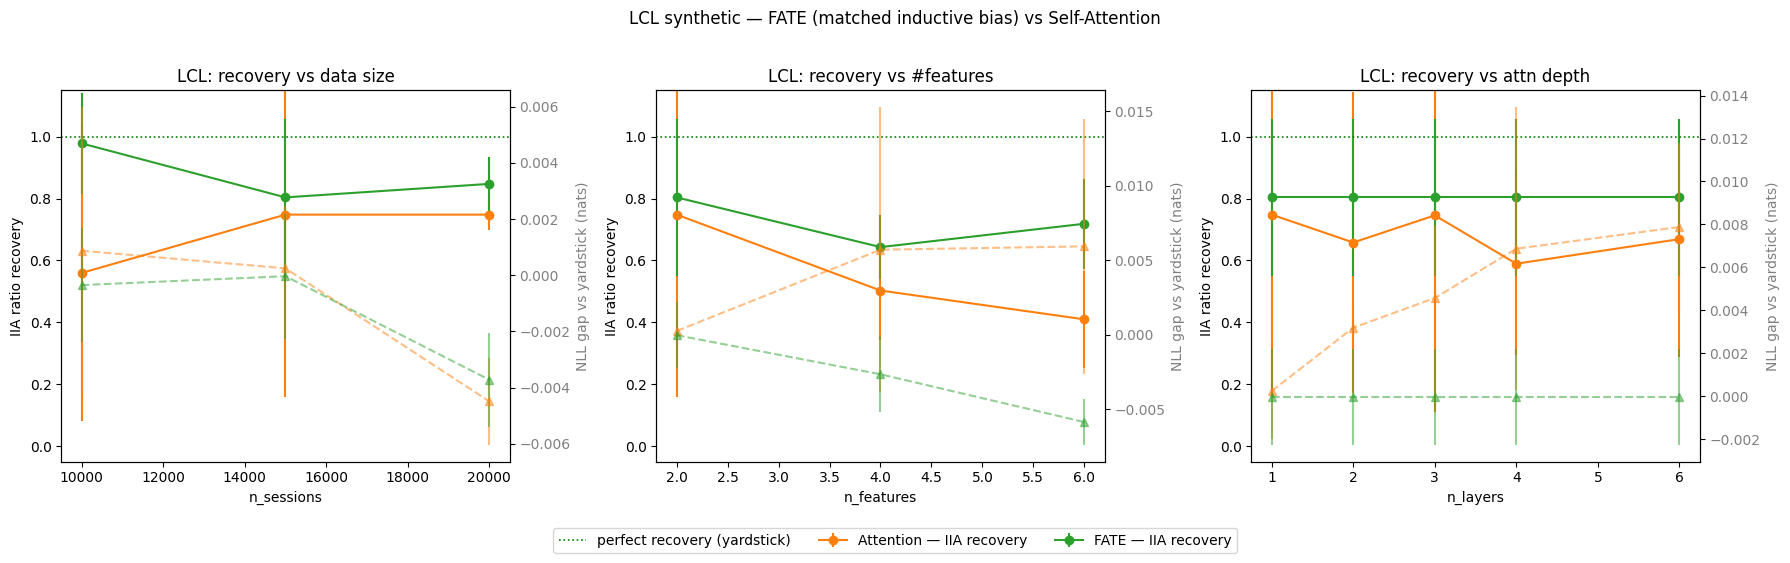

saved lcl_fate_vs_attn.png


In [ ]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

def plot_lcl_panel(ax, xs, accum, xlabel, title):
    for name,color in [("Attention","C1"),("FATE","C2")]:
        ax.errorbar(xs, accum[name]["iia"][0], yerr=accum[name]["iia"][1],
                    marker="o", label=f"{name} — IIA recovery", color=color)
    ax.axhline(1.0, ls=":", c="green", lw=1.2, label="perfect recovery (yardstick)")
    ax.set_xlabel(xlabel); ax.set_ylabel("IIA ratio recovery")
    ax.set_title(title); ax.set_ylim(-0.05,1.15)
    ax2 = ax.twinx()
    for name,color in [("Attention","C1"),("FATE","C2")]:
        ax2.errorbar(xs, accum[name]["nll_gap"][0], yerr=accum[name]["nll_gap"][1],
                     marker="^", ls="--", color=color, alpha=0.5,
                     label=f"{name} — NLL gap")
    ax2.set_ylabel("NLL gap vs yardstick (nats)", color="grey")
    ax2.tick_params(axis="y", labelcolor="grey")
    return ax2

plot_lcl_panel(axes[0], lxs_s, lres_s, "n_sessions", "LCL: recovery vs data size")
plot_lcl_panel(axes[1], lxs_f, lres_f, "n_features",  "LCL: recovery vs #features")
plot_lcl_panel(axes[2], lxs_l, lres_l, "n_layers",    "LCL: recovery vs attn depth")

handles,labels = axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc="lower center",ncol=4,bbox_to_anchor=(0.5,-0.08))
plt.suptitle("LCL synthetic — FATE (matched inductive bias) vs Self-Attention", y=1.02)
plt.tight_layout()
plt.savefig("lcl_fate_vs_attn.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved lcl_fate_vs_attn.png")

### Cell 20 — Combined summary table

All results in one dataframe — both datasets, both models, all three sweeps. Ready to copy into the thesis.


In [ ]:
rows = []
for dataset, sweep_results in [
    ("CDM", [(xs_s,res_s,"n_sessions"),(xs_f,res_f,"n_features"),(xs_l,res_l,"n_layers")]),
    ("LCL", [(lxs_s,lres_s,"n_sessions"),(lxs_f,lres_f,"n_features"),(lxs_l,lres_l,"n_layers")]),
]:
    model_key = "FETA" if dataset=="CDM" else "FATE"
    for xs, accum, swept in sweep_results:
        for i,v in enumerate(xs):
            rows.append({
                "dataset": dataset, "swept": swept, "value": v,
                "attn_iia":  round(accum["Attention"]["iia"][0][i],4),
                "model_iia": round(accum[model_key]["iia"][0][i],4),
                "model":     model_key,
                "attn_nll_gap":  round(accum["Attention"]["nll_gap"][0][i],4),
                "model_nll_gap": round(accum[model_key]["nll_gap"][0][i],4),
            })

summary = pd.DataFrame(rows)
summary.to_csv("comparison_summary.csv", index=False)
print(summary.to_string(index=False))
print("\nsaved comparison_summary.csv")

dataset      swept  value  attn_iia  model_iia model  attn_nll_gap  model_nll_gap
    CDM n_sessions  10000    0.6193     0.7425  FETA        0.0306         0.0560
    CDM n_sessions  15000    0.6398     0.7910  FETA        0.0262         0.0333
    CDM n_sessions  20000    0.6832     0.8257  FETA        0.0254         0.0225
    CDM n_features      2    0.6814     0.8277  FETA        0.0114         0.0169
    CDM n_features      4    0.4787     0.7127  FETA        0.0466         0.0809
    CDM n_features      6    0.4305     0.4770  FETA        0.1404         0.1581
    CDM   n_layers      1    0.6921     0.7910  FETA        0.0145         0.0333
    CDM   n_layers      2    0.6398     0.7910  FETA        0.0262         0.0333
    CDM   n_layers      3    0.6115     0.7910  FETA        0.0395         0.0333
    CDM   n_layers      4    0.5884     0.7910  FETA        0.0479         0.0333
    CDM   n_layers      6    0.5775     0.7910  FETA        0.0598         0.0333
    LCL n_sessio

### Cell 21 — Reading the results

**If FETA consistently outperforms Attention on CDM IIA recovery, and FATE consistently outperforms Attention on LCL IIA recovery**, this is the inductive-bias hypothesis confirmed in controlled synthetic conditions. The argument it makes:

- Self-attention *can* represent context effects (it has enough parameters) but the cross-entropy objective cannot teach it the *right* effect — this is the identification failure we already showed.
- A model whose architecture matches the true effect structure gets the right answer from the same data and the same objective — because the functional form constrains the solution space in the right way.
- This means the problem is not "does the model need to be bigger" — it's "does the model need the right inductive bias."

**This directly motivates the target-conditioned extension** ($A_{c,S} = g(\text{embed}(c), \{\text{embed}(j)\}_{j \in S})$): instead of imposing the right bias through architecture (which requires knowing the effect structure in advance), you learn it from the data by conditioning the similarity metric on the target and the set. That is the open research contribution these experiments are building toward.
